In [101]:
# demo KNN Classifier for Data Analysis
# Dr.Steven Lindo
# SpringBoard Incubators, Inc.
# Summer 2024
# Revision History
# Name    Date        Description
# scl     07/06/24    Initial code base
# scl     02/19/25    Update for ULoLI DS course
#
# -   -   -   -   -   -   -   -   -   -   -   -   -

In [102]:
import os
from google.colab import drive
drive.mount('/content/drive')

location ='drive/MyDrive/ULoLI_Data_Analyst/Feb_Cohort/datafiles/'
list_of_files = os.listdir(location)
list_of_files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['grades.gsheet',
 'LifeExpectancyData.csv',
 'heart.csv',
 'grades.csv',
 'solar_panel_compare.csv',
 'Yanick_alaska-pipeline (1).csv',
 'bmi_sample_data.csv',
 'sports_class.csv',
 'prostate_cancer_upd.csv',
 'Yanick_sports_class.csv',
 'bc_data-1.csv',
 'alaska-pipeline.csv']

In [103]:
# import standard data science libraries
import numpy as np
import pandas as pd
import seaborn as sns

# cheat a little with the random state seed
from datetime import datetime
SEED = datetime.now().second

In [104]:
# import specific libraries for AI / ML
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, \
ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, f1_score, roc_auc_score

In [105]:
def loadDataIris():
  x_features = load_iris(return_X_y=False, as_frame=True).data
  y_targets = load_iris(return_X_y=False, as_frame=True).target
  return x_features, y_targets.values.ravel()

def loadData(ln, fn):
  df = pd.read_csv(ln+fn)
  y_targets  = df.iloc[:,-1:]     # assumes that the last column is the y_targets
  X_features = df.iloc[:,:-1]     # assumes that all the other columns are X_features
  return X_features, y_targets.values.ravel()


In [106]:
# Load the X - Features and the y - observations
# X, y = loadDataIris()
filename = 'heart.csv'
if filename in list_of_files:
  X, y = loadData(location, filename)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# get the numberic values only from X
X = X.select_dtypes(include='number')

# split the data set into a training set and a test set
# the reason you do this is to test the model to see how accurate
# in will perform when predicting the classifications
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.3, random_state=SEED)

In [107]:
# Next import the AI / ML model you want to use
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# create the model
# model = KNeighborsClassifier(n_neighbors=5)
# model = GaussianNB()
# model = SVC()
model = DecisionTreeClassifier()
# model = RandomForestClassifier()

# train the model
model.fit(X_train, y_train)

predict_row = X_test.sample(1, random_state=SEED)
print('\n-  -  -  -  -  -  -  -  Use the model to classify this row   -  -  -  -  -  -  \n', predict_row.T)
print('-  -  -  -  -  -   -  -  -  -  -  -  -  -  -  -  -  -  -  -  -   -  -  -  -  -\n')

predict = model.predict(predict_row)
actual  = y[predict_row.index]

print('Predicted = ', predict)
print('Actual    = ', actual)

print('\nModel Accuracy = ', round(model.score(X_test, y_test), 4))
print('-  -  -  -  -  -   -  -  -  -  -  -  -  -  -  -  -  -  -  -  -   -  -  -  -  -\n')


-  -  -  -  -  -  -  -  Use the model to classify this row   -  -  -  -  -  -  
                259
Age           55.0
RestingBP    122.0
Cholesterol  320.0
FastingBS      0.0
MaxHR        155.0
Oldpeak        0.0
-  -  -  -  -  -   -  -  -  -  -  -  -  -  -  -  -  -  -  -  -   -  -  -  -  -

Predicted =  [0]
Actual    =  [0]

Model Accuracy =  0.6936
-  -  -  -  -  -   -  -  -  -  -  -  -  -  -  -  -  -  -  -  -   -  -  -  -  -



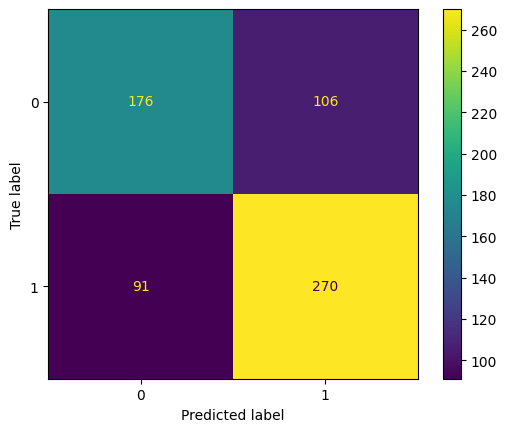

In [108]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

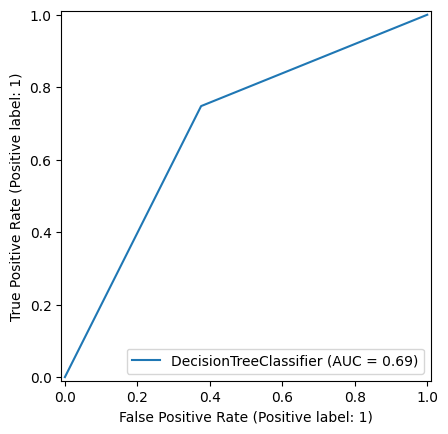

In [109]:
RocCurveDisplay.from_estimator(model, X_test, y_test)

In [110]:
roc_auc_score(y_test, model.predict(X_test))

0.6860179564252176

In [111]:
f1_score(y_test, model.predict(X_test))

0.7327001356852103

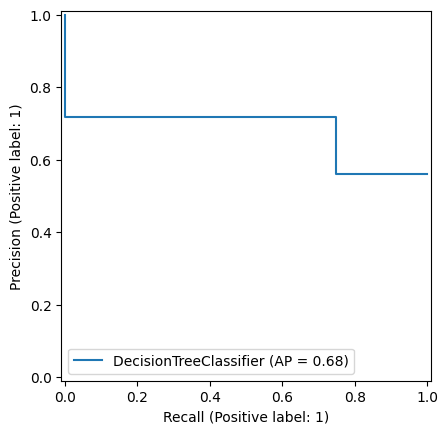

In [112]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)

In [113]:
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.66      0.62      0.64       282
           1       0.72      0.75      0.73       361

    accuracy                           0.69       643
   macro avg       0.69      0.69      0.69       643
weighted avg       0.69      0.69      0.69       643

